In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df_routes = pd.read_csv("routes.csv")
stop_df = pd.read_csv("route_stops.csv")

In [18]:
df_routes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   route_id               200 non-null    object 
 1   vehicle_id             200 non-null    object 
 2   vehicle_type           200 non-null    object 
 3   driver_id              200 non-null    object 
 4   num_stops              200 non-null    int64  
 5   departure_planned      200 non-null    object 
 6   departure_actual       200 non-null    object 
 7   total_distance_km      200 non-null    float64
 8   planned_duration_min   200 non-null    float64
 9   actual_duration_min    200 non-null    float64
 10  total_delay_min        200 non-null    float64
 11  on_time_delivery_rate  200 non-null    float64
 12  weather_condition      200 non-null    object 
 13  temperature_c          200 non-null    float64
 14  precipitation_mm       200 non-null    float64
 15  wind_s

In [19]:
stop_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1451 entries, 0 to 1450
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   route_id               1451 non-null   object 
 1   stop_sequence          1451 non-null   int64  
 2   stop_id                1451 non-null   object 
 3   latitude               1451 non-null   float64
 4   longitude              1451 non-null   float64
 5   distance_from_prev_km  1451 non-null   float64
 6   road_type              1451 non-null   object 
 7   planned_arrival        1451 non-null   object 
 8   actual_arrival         1451 non-null   object 
 9   time_window_open       1451 non-null   object 
 10  time_window_close      1451 non-null   object 
 11  planned_service_min    1451 non-null   float64
 12  actual_service_min     1451 non-null   float64
 13  planned_travel_min     1451 non-null   float64
 14  actual_travel_min      1451 non-null   float64
 15  dela

In [20]:
df_routes.describe()

,num_stops,total_distance_km,planned_duration_min,actual_duration_min,total_delay_min,on_time_delivery_rate,temperature_c,precipitation_mm,wind_speed_kmh,humidity_pct,visibility_km,road_incident,incident_severity,overall_delay_factor
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,7.255000,225.053900,334.691000,590.314000,255.623000,0.146155,17.501000,3.037000,14.210500,63.936000,14.232000,0.085000,0.078350,1.963400
std,1.979791,74.610031,123.120144,315.433873,240.917208,0.225348,10.468296,5.653836,13.819593,20.289466,8.226845,0.279582,0.279646,0.806257
min,4.000000,66.280000,90.300000,104.400000,-6.100000,0.000000,-2.500000,0.000000,0.000000,30.000000,0.700000,0.000000,0.000000,0.916000
25%,6.000000,169.607500,237.525000,378.900000,96.775000,0.000000,8.950000,0.000000,4.950000,46.775000,7.900000,0.000000,0.000000,1.378000
50%,7.000000,224.860000,318.800000,537.050000,190.800000,0.000000,17.850000,0.000000,10.100000,63.300000,12.300000,0.000000,0.000000,1.732000
75%,9.000000,274.277500,412.925000,712.700000,334.575000,0.200000,26.900000,3.075000,14.625000,81.625000,21.350000,0.000000,0.000000,2.292750
max,10.000000,429.780000,719.800000,2117.100000,1633.800000,1.000000,34.800000,19.900000,58.300000,99.900000,29.800000,1.000000,1.440000,5.071000


In [30]:
df_routes.columns

Index(['route_id', 'vehicle_id', 'vehicle_type', 'driver_id', 'num_stops',
       'departure_planned', 'departure_actual', 'total_distance_km',
       'planned_duration_min', 'actual_duration_min', 'total_delay_min',
       'on_time_delivery_rate', 'weather_condition', 'temperature_c',
       'precipitation_mm', 'wind_speed_kmh', 'humidity_pct', 'visibility_km',
       'traffic_level', 'road_incident', 'incident_severity',
       'overall_delay_factor'],
      dtype='object')

In [31]:
stop_df.columns

Index(['route_id', 'stop_sequence', 'stop_id', 'latitude', 'longitude',
       'distance_from_prev_km', 'road_type', 'planned_arrival',
       'actual_arrival', 'time_window_open', 'time_window_close',
       'planned_service_min', 'actual_service_min', 'planned_travel_min',
       'actual_travel_min', 'delay_at_stop_min', 'missed_time_window',
       'delay_probability', 'package_count', 'package_weight_kg'],
      dtype='object')

In [21]:
stop_df.describe()

,stop_sequence,latitude,longitude,distance_from_prev_km,planned_service_min,actual_service_min,planned_travel_min,actual_travel_min,delay_at_stop_min,missed_time_window,delay_probability,package_count,package_weight_kg
count,1451.000000,1451.000000,1451.000000,1451.000000,1451.000000,1451.000000,1451.000000,1451.000000,1451.000000,1451.000000,1451.000000,1451.000000,1451.000000
mean,4.396278,39.510486,37.104996,31.020524,12.382977,14.911785,33.749483,66.454721,32.705238,0.855961,0.392619,10.445899,25.057684
std,2.477643,0.173538,0.174227,15.106028,4.290195,5.917214,19.736834,50.840616,37.262122,0.351250,0.180789,5.817838,14.403574
min,1.000000,39.200212,36.801602,0.880000,5.000000,4.100000,0.800000,1.000000,-2.900000,0.000000,0.000000,1.000000,0.500000
25%,2.000000,39.366133,36.953176,19.510000,8.650000,10.250000,18.550000,31.000000,8.400000,1.000000,0.261000,5.000000,12.000000
50%,4.000000,39.506125,37.107949,30.450000,12.400000,14.400000,30.600000,53.200000,20.300000,1.000000,0.376000,11.000000,25.200000
75%,6.000000,39.662402,37.256250,42.430000,16.000000,18.900000,45.700000,89.850000,43.800000,1.000000,0.519500,15.500000,37.600000
max,10.000000,39.799757,37.399973,74.220000,20.000000,31.600000,99.000000,391.400000,314.200000,1.000000,0.934000,20.000000,50.000000


In [22]:
stop_df

,route_id,stop_sequence,stop_id,latitude,longitude,distance_from_prev_km,road_type,planned_arrival,actual_arrival,time_window_open,time_window_close,planned_service_min,actual_service_min,planned_travel_min,actual_travel_min,delay_at_stop_min,missed_time_window,delay_probability,package_count,package_weight_kg
0,RT-0001,1,STP-95181,39.620795,37.051712,9.85,mountain,2025-02-23 15:56:52,2025-02-23 16:05:16,2025-02-23 15:46:52,2025-02-23 16:11:52,11.7,12.0,13.1,21.5,8.4,0,0.370,11,14.3
1,RT-0001,2,STP-38221,39.774328,37.001957,17.59,mountain,2025-02-23 16:32:04,2025-02-23 16:55:52,2025-02-23 16:11:04,2025-02-23 17:01:04,6.4,5.6,23.5,38.6,15.1,0,0.283,2,36.6
2,RT-0001,3,STP-80284,39.274896,37.353377,63.19,mountain,2025-02-23 18:02:46,2025-02-23 19:19:52,2025-02-23 17:32:46,2025-02-23 18:31:46,6.2,6.4,84.3,138.4,54.1,1,0.407,12,29.1
3,RT-0001,4,STP-19116,39.227495,36.936739,36.26,mountain,2025-02-23 18:57:16,2025-02-23 20:45:34,2025-02-23 18:40:16,2025-02-23 19:10:16,9.3,8.0,48.3,79.3,31.0,1,0.306,15,32.0
4,RT-0001,5,STP-57819,39.297592,37.013162,10.20,mountain,2025-02-23 19:20:10,2025-02-23 21:15:52,2025-02-23 18:50:10,2025-02-23 19:32:10,15.1,20.6,13.6,22.3,8.7,1,0.352,6,26.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1446,RT-0200,6,STP-85464,39.240890,36.813233,57.31,rural,2025-03-25 07:54:24,2025-03-25 08:34:00,2025-03-25 07:42:24,2025-03-25 08:10:24,17.5,15.2,52.9,64.7,11.8,1,0.284,4,29.5
1447,RT-0200,7,STP-42543,39.414648,37.253295,42.50,rural,2025-03-25 08:51:06,2025-03-25 09:37:12,2025-03-25 08:35:06,2025-03-25 09:14:06,14.0,20.3,39.2,48.0,8.8,1,0.106,7,24.0
1448,RT-0200,8,STP-63429,39.736665,37.005037,41.65,rural,2025-03-25 09:43:30,2025-03-25 10:44:30,2025-03-25 09:25:30,2025-03-25 10:03:30,19.7,16.5,38.4,47.0,8.6,1,0.196,4,20.3
1449,RT-0200,9,STP-12874,39.746006,37.016190,1.41,rural,2025-03-25 10:04:30,2025-03-25 11:02:36,2025-03-25 09:39:30,2025-03-25 10:18:30,19.3,27.0,1.3,1.6,0.3,1,0.137,20,5.3


In [23]:
df_routes

,route_id,vehicle_id,vehicle_type,driver_id,num_stops,departure_planned,departure_actual,total_distance_km,planned_duration_min,actual_duration_min,...,weather_condition,temperature_c,precipitation_mm,wind_speed_kmh,humidity_pct,visibility_km,traffic_level,road_incident,incident_severity,overall_delay_factor
0,RT-0001,VH-1409,van,DR-859,9,2025-02-23 15:43:46,2025-02-23 15:48:18,241.81,418.1,645.7,...,cloudy,7.8,0.0,11.0,77.4,27.3,low,1,0.32,1.642
1,RT-0002,VH-9669,car,DR-357,8,2025-04-18 16:13:10,2025-04-18 16:12:05,351.46,333.8,424.5,...,clear,23.8,0.0,1.7,91.9,23.8,high,0,0.00,1.328
2,RT-0003,VH-1993,van,DR-512,9,2025-05-22 15:43:16,2025-05-22 15:51:32,380.96,465.8,696.6,...,rain,28.0,2.2,2.9,67.5,8.5,moderate,0,0.00,1.625
3,RT-0004,VH-4335,motorcycle,DR-803,9,2025-05-04 09:45:47,2025-05-04 09:48:53,324.82,324.0,973.9,...,rain,17.7,5.0,13.6,33.6,20.9,high,1,1.20,3.869
4,RT-0005,VH-6344,car,DR-512,6,2025-05-16 15:13:36,2025-05-16 15:16:18,93.59,167.7,239.9,...,rain,19.4,3.8,10.0,56.5,23.7,moderate,0,0.00,1.613
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,RT-0196,VH-9535,motorcycle,DR-206,9,2025-01-30 07:20:04,2025-01-30 07:22:20,381.84,460.4,669.0,...,rain,6.2,1.8,0.3,69.1,14.9,moderate,0,0.00,1.535
196,RT-0197,VH-3242,van,DR-956,10,2025-06-07 13:16:58,2025-06-07 13:31:55,342.46,347.4,414.3,...,rain,16.2,0.1,0.7,34.2,8.0,low,0,0.00,1.210
197,RT-0198,VH-3820,motorcycle,DR-143,4,2025-02-19 20:49:02,2025-02-19 20:54:58,117.83,198.1,598.8,...,fog,21.3,0.0,0.6,71.3,6.6,congested,0,0.00,3.432
198,RT-0199,VH-9856,car,DR-964,8,2025-02-03 13:22:45,2025-02-03 13:34:11,230.12,315.9,710.1,...,clear,3.1,0.0,0.8,41.1,21.6,low,1,1.41,2.752


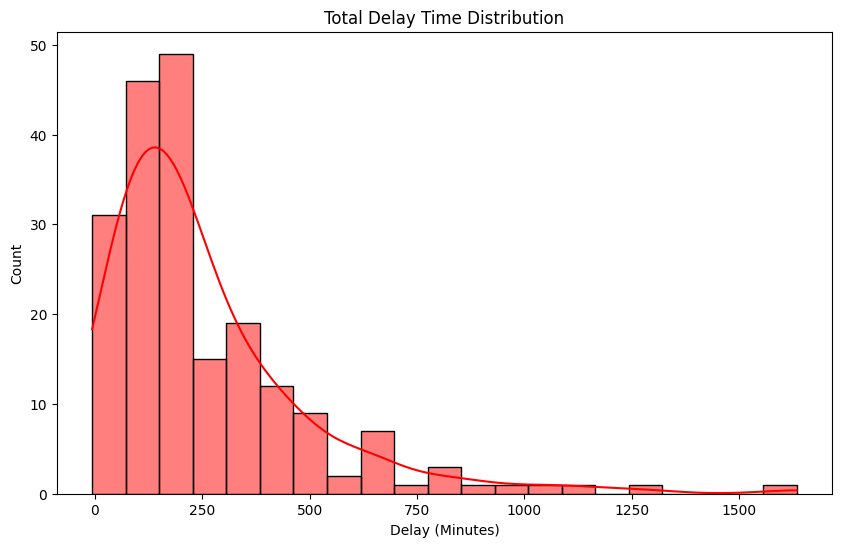

In [24]:
plt.figure(figsize=(10, 6))
sns.histplot(df_routes['total_delay_min'], kde=True, color='red')
plt.title('Total Delay Time Distribution')
plt.xlabel('Delay (Minutes)')
plt.show()

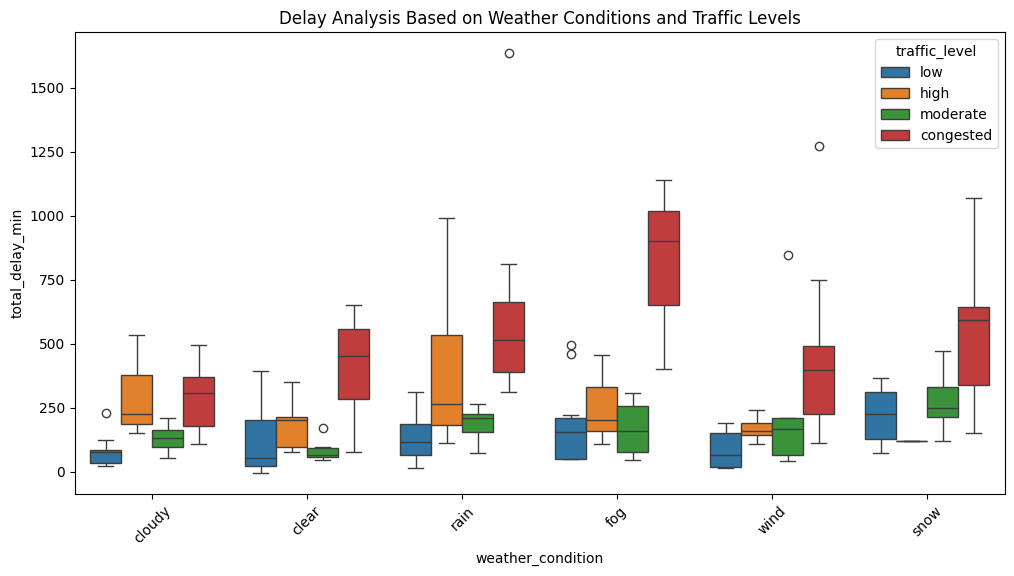

In [25]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='weather_condition', y='total_delay_min', data=df_routes, hue='traffic_level')
plt.title('Delay Analysis Based on Weather Conditions and Traffic Levels')
plt.xticks(rotation=45)
plt.show()

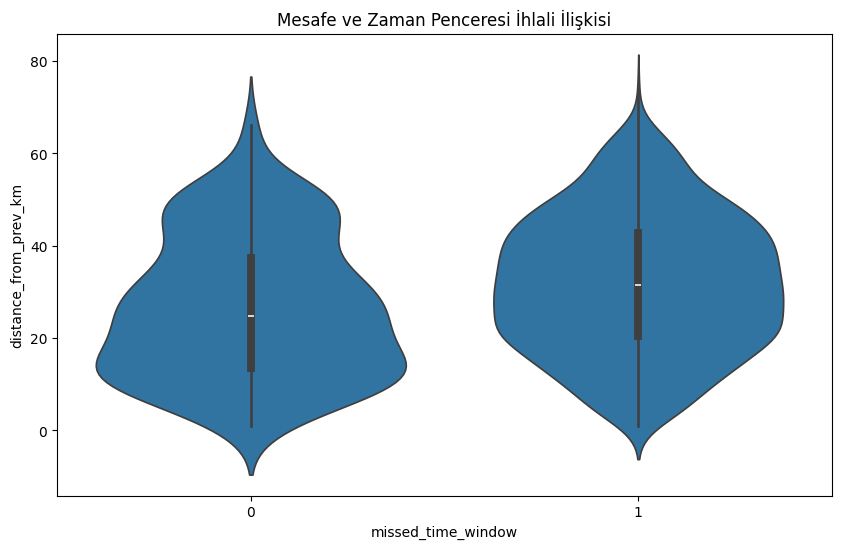

In [27]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='missed_time_window', y='distance_from_prev_km', data=stop_df)
plt.title('The Relationship Between Distance and Time Window Violation')
plt.show()

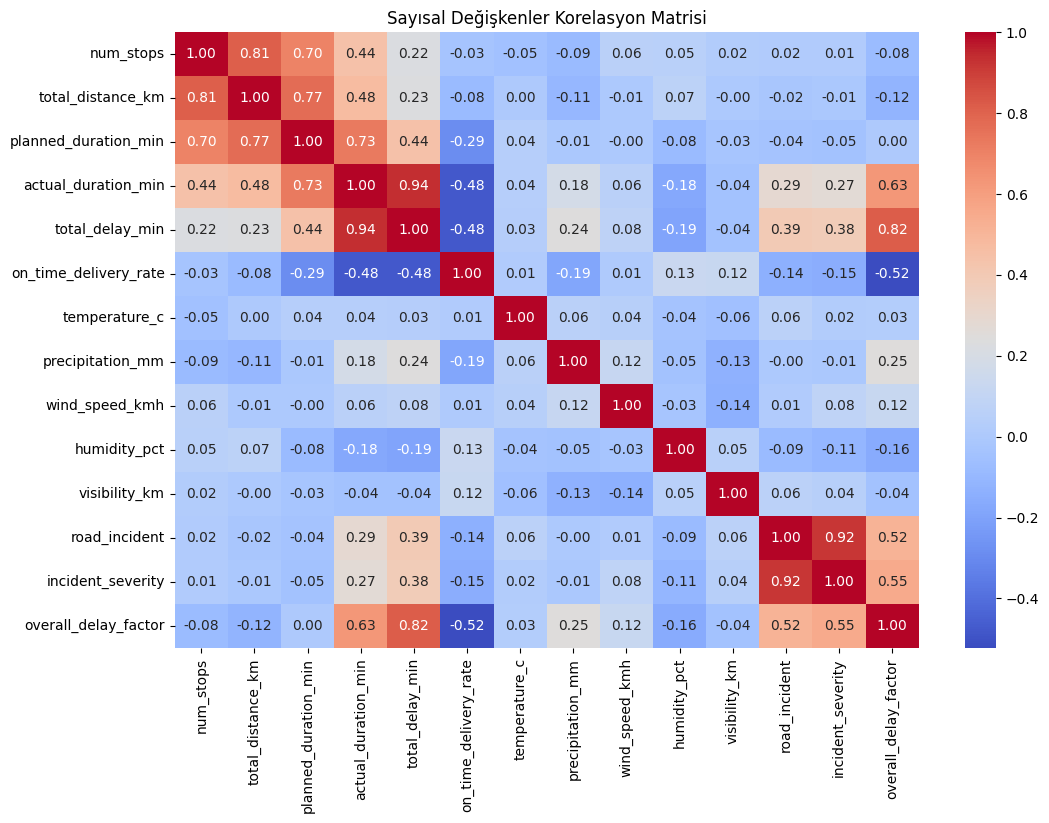

In [28]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_routes.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

In [29]:
# drop the road_incident. incident_severity is have more information.
# actual_duration_min will have data leakage. this column will drop.

In [ ]:
import pandas as pd
import numpy as np

# we are drop this column because this column It leads to data leakage.
cols_to_drop = ['actual_duration_min', 'on_time_delivery_rate', 'overall_delay_factor']
df_ml = df_routes.drop(columns=cols_to_drop)

# multicollinearity cleaning.
df_ml = df_ml.drop(columns=['road_incident'])

# we drop outliers. we want have 500 minutes on top.
p95_limit = df_ml['total_delay_min'].quantile(0.95)
df_ml['total_delay_min'] = np.clip(df_ml['total_delay_min'], a_min=None, a_max=p95_limit)

# one hot encoding time.
df_ml = pd.get_dummies(df_ml, columns=['weather_condition', 'traffic_level'], drop_first=True)

# only numerical values can be selected for x and y values.
y = df_ml['total_delay_min']
X = df_ml.drop(columns=[
    'total_delay_min', 
    'route_id', 
    'vehicle_id', 
    'driver_id', 
    'departure_planned', 
    'departure_actual'
])

print("Model için hazır X matrisi boyutu:", X.shape)
display(X.head())